In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import Ridge
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import LabelEncoder
import warnings
from pathlib import Path
import sys
import os
from datetime import datetime

project_root = Path.cwd().parent.parent
project_root_str = str(project_root)

if project_root_str not in sys.path:
    sys.path.insert(0, project_root_str)

os.chdir(project_root_str)

from src.utils.team_info import *
from src.utils.helper_functions import *
from src.pipeline.props_pipeline.ppm_pipeline import *
from src.pipeline.props_pipeline.min_pipeline import *
from src.pipeline.props_pipeline.rpm_pipeline import *
from src.features.feature_engineer.rpm_features import *

warnings.filterwarnings("ignore")

In [2]:
pd.set_option('display.max_columns', None)

s23 = pd.read_csv('data/raw/season_stats/S23.csv').sort_values(by='GAME_DATE')
s24 = pd.read_csv('data/raw/season_stats/S24.csv').sort_values(by='GAME_DATE')
s25 = pd.read_csv('data/raw/season_stats/S25.csv').sort_values(by='GAME_DATE')
s25['STARTING'] = s25['START_POSITION'].notna().astype(int)
s26 = pd.read_csv('data/raw/season_stats/S26.csv').sort_values(by='GAME_DATE')
s26['STARTING'] = s26['START_POSITION'].notna().astype(int)
s26.tail()

,SEASON_YEAR,PLAYER_ID,PLAYER_NAME,NICKNAME,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,MATCHUP,WL,MIN,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,FTA,FT_PCT,OREB,DREB,REB,AST,TOV,STL,BLK,BLKA,PF,PFD,PTS,PLUS_MINUS,NBA_FANTASY_PTS,DD2,TD3,WNBA_FANTASY_PTS,AVAILABLE_FLAG,MIN_SEC,TEAM_COUNT,E_OFF_RATING,OFF_RATING,sp_work_OFF_RATING,E_DEF_RATING,DEF_RATING,sp_work_DEF_RATING,E_NET_RATING,NET_RATING,sp_work_NET_RATING,AST_PCT,AST_TO,AST_RATIO,OREB_PCT,DREB_PCT,REB_PCT,TM_TOV_PCT,E_TOV_PCT,EFG_PCT,TS_PCT,USG_PCT,E_USG_PCT,E_PACE,PACE,PACE_PER40,sp_work_PACE,PIE,POSS,FGM_PG,FGA_PG,TEAM_FGM,TEAM_FGA,TEAM_FG_PCT,TEAM_FG3M,TEAM_FG3A,TEAM_FG3_PCT,TEAM_FTM,TEAM_FTA,TEAM_FT_PCT,TEAM_OREB,TEAM_DREB,TEAM_REB,TEAM_AST,TEAM_TOV,TEAM_STL,TEAM_BLK,TEAM_BLKA,TEAM_PF,TEAM_PFD,TEAM_PTS,TEAM_PLUS_MINUS,TEAM_E_OFF_RATING,TEAM_OFF_RATING,TEAM_E_DEF_RATING,TEAM_DEF_RATING,TEAM_E_NET_RATING,TEAM_NET_RATING,TEAM_AST_PCT,TEAM_AST_TO,TEAM_AST_RATIO,TEAM_OREB_PCT,TEAM_DREB_PCT,TEAM_REB_PCT,TEAM_TM_TOV_PCT,TEAM_EFG_PCT,TEAM_TS_PCT,TEAM_E_PACE,TEAM_PACE,TEAM_PACE_PER40,TEAM_POSS,TEAM_PIE,OPP_TEAM_ID,OPP_OPP_ABBREVIATION_base,OPP_OPP_NAME_base,OPP_FGM,OPP_FGA,OPP_FG_PCT,OPP_FG3M,OPP_FG3A,OPP_FG3_PCT,OPP_FTM,OPP_FTA,OPP_FT_PCT,OPP_OREB,OPP_DREB,OPP_REB,OPP_AST,OPP_TOV,OPP_STL,OPP_BLK,OPP_BLKA,OPP_PF,OPP_PFD,OPP_PTS,OPP_PLUS_MINUS,OPP_E_OFF_RATING,OPP_OFF_RATING,OPP_E_DEF_RATING,OPP_DEF_RATING,OPP_E_NET_RATING,OPP_NET_RATING,OPP_AST_PCT,OPP_AST_TO,OPP_AST_RATIO,OPP_OREB_PCT,OPP_DREB_PCT,OPP_REB_PCT,OPP_TM_TOV_PCT,OPP_EFG_PCT,OPP_TS_PCT,OPP_E_PACE,OPP_PACE,OPP_PACE_PER40,OPP_POSS,OPP_PIE,START_POSITION,pos,age,STARTING
209,2025-26,201145,Jeff Green,Jeff,1610612745,HOU,Houston Rockets,22501194,2026-04-12T00:00:00,HOU vs. MEM,W,24.183333,2,8,0.250,0,4,0.00,2,2,1.000,2,3,5,1,3,1,1,0,2,1,6,7,16.5,0,0,16.0,1,24:11,1,103.9,105.5,105.5,86.1,91.1,91.1,17.8,14.4,14.4,0.059,0.33,7.7,0.063,0.100,0.081,23.1,23.3,0.250,0.338,0.174,0.181,114.13,110.16,91.80,110.16,0.016,55,2.0,8.0,48,105,0.457,14,49,0.286,22,30,0.733,21,43,64,23,11.0,10,8,6,10,24,132,31.0,122.0,128.2,94.9,98.1,27.1,30.1,0.479,2.09,14.9,0.452,0.821,0.627,0.107,0.524,0.558,107.3,103.0,85.83,103,0.642,1610612763,MEM,Memphis Grizzlies,39,95,0.411,13,49,0.265,10,10,1.000,6,31,37,23,13.0,8,6,8,24,10,101,-31.0,94.9,98.1,122.0,128.2,-27.1,-30.1,0.590,1.77,16.9,0.179,0.548,0.373,0.126,0.479,0.508,107.3,103.0,85.83,103,0.358,NaN,PF,39.0,0
210,2025-26,1631342,Daeqwon Plowden,Daeqwon,1610612758,SAC,Sacramento Kings,22501200,2026-04-12T00:00:00,SAC @ POR,L,22.200000,2,5,0.400,1,4,0.25,3,3,1.000,0,1,1,2,3,0,2,0,4,1,8,-8,15.2,0,0,16.0,1,22:12,1,118.2,114.6,114.6,127.2,134.0,134.0,-9.0,-19.5,-19.5,0.100,0.67,18.2,0.000,0.034,0.022,27.3,26.5,0.500,0.633,0.173,0.184,103.83,102.70,85.59,102.70,0.017,48,2.0,5.0,40,83,0.482,7,21,0.333,23,31,0.742,15,32,47,24,17.0,7,8,3,18,21,110,-12.0,111.5,112.2,120.1,123.2,-8.6,-11.0,0.600,1.41,17.3,0.370,0.600,0.495,0.173,0.524,0.569,100.1,98.5,82.08,98,0.478,1610612757,POR,Portland Trail Blazers,47,101,0.465,16,46,0.348,12,15,0.800,18,28,46,28,12.0,9,3,8,21,18,122,12.0,120.1,123.2,111.5,112.2,8.6,11.0,0.596,2.33,18.8,0.400,0.630,0.505,0.121,0.545,0.567,100.1,98.5,82.08,99,0.522,F,SG,27.0,1
211,2025-26,1630286,Trevon Scott,Trevon,1610612751,BKN,Brooklyn Nets,22501192,2026-04-12T00:00:00,BKN @ TOR,L,26.050000,3,8,0.375,2,5,0.40,0,0,0.000,1,2,3,1,2,1,0,0,2,0,8,-17,14.1,0,0,16.0,1,26:03,1,104.8,109.3,109.3,137.8,135.7,135.7,-32.9,-26.5,-26.5,0.053,0.50,9.1,0.038,0.125,0.071,18.2,18.2,0.500,0.500,0.164,0.161,102.67,101.34,84.45,101.34,0.027,54,3.0,8.0,35,86,0.407,9,34,0.265,22,29,0.759,13,25,38,21,16.0,9,0,8,27,20,101,-35.0,99.3,101.0,136.3,136.0,-37.1,-35.0,0.600,1.31,15.6,0.255,0.844,0.471,0.160,0.459,0.511,100.8,100.0,83.33,100,0.277,1610612761,TOR,Toronto Raptors,51,80,0.638,12,27,0.444,22,29,0.759,3,40,43,36,10.0,9,8,0,20,27,136,35.0,136.3,136.0,99.3,101.0,37.1,35.0,0.706,3.60,25.5,0.156,0.745,0.529,0.100,0.713,0.733,100.8,100.0,83.33,100,0.723,C,NaN,NaN,1
204,2025-26,1629020,Jarred Vande

In [3]:
res = []
for df in [s23, s24, s25, s26]:
    df["GAME_DATE"] = pd.to_datetime(df["GAME_DATE"])
    df = df.sort_values(["PLAYER_ID", "GAME_DATE"]).reset_index(drop=True)

    # Derived features
    df['MIN'] = df['MIN'].round(2)
    df["REB_PER_MIN"] = df["REB"] / df["MIN"].replace(0, np.nan)
    df["OREB_PER_MIN"] = df["OREB"] / df["MIN"].replace(0, np.nan)
    df["DREB_PER_MIN"] = df["DREB"] / df["MIN"].replace(0, np.nan)
    df = rpm_features(df)
    df['TEAM_REB_RANK_L5'] = (df.groupby(['TEAM_ID','GAME_DATE'])['REB_roll5'].rank(ascending=False, method='dense'))
    df['TEAM_REB_PER_MIN_RANK_L10'] = (df.groupby(['TEAM_ID','GAME_DATE'])['REB_PER_MIN_roll10'].rank(ascending=False, method='dense'))
    df['TEAM_MIN_RANK_L10'] = (df.groupby(['TEAM_ID','GAME_DATE'])['MIN_roll10'].rank(ascending=False, method='dense'))
    df['MEDIAN_REB_PER_MIN_L10'] = (df.groupby('PLAYER_ID')['REB_PER_MIN'].transform(lambda x: x.shift(1).rolling(10).median().round(2)))
    df['REB_PER_MIN_ewm5'] = (df.groupby('PLAYER_ID')['REB_PER_MIN'].transform(lambda x: x.shift(1).ewm(span=5, adjust=False).mean()))
    df['REB_PER_MIN_ewm10'] = (df.groupby('PLAYER_ID')['REB_PER_MIN'].transform(lambda x: x.shift(1).ewm(span=10, adjust=False).mean()))
    df['REB_PER_MIN_TREND'] = df['REB_PER_MIN_ewm10'] - df['REB_PER_MIN_ewm5']
    df['REB_ewm10'] = (df.groupby('PLAYER_ID')['REB'].transform(lambda x: x.shift(1).ewm(span=10, adjust=False).mean()))
    df['MIN_ewm10'] = (df.groupby('PLAYER_ID')['MIN'].transform(lambda x: x.shift(1).ewm(span=10, adjust=False).mean()))
    df["GP"] = df.groupby("PLAYER_ID").cumcount()
    df['POSITION_ENC'] = LabelEncoder().fit_transform(df['pos'])
    player_avgs = df[df['MIN'] > 0].groupby('PLAYER_ID')['MIN'].apply(
    lambda x: (x >= 12).mean())
    eligible = player_avgs[player_avgs >= 0.60].index
    df = df[df['PLAYER_ID'].isin(eligible)]
    res.append(df)

df = pd.concat(res, ignore_index=True)
df.drop(columns=['Unnamed: 0'], inplace=True)
print(df.shape)
df.to_csv('data/processed/training/S26_TRAINING_RPM.csv', index=False)
df.tail()

(84497, 251)


,SEASON_YEAR,PLAYER_ID,PLAYER_NAME,NICKNAME,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,MATCHUP,WL,MIN,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,FTA,FT_PCT,OREB,DREB,REB,AST,TOV,STL,BLK,BLKA,PF,PFD,PTS,PLUS_MINUS,NBA_FANTASY_PTS,DD2,TD3,WNBA_FANTASY_PTS,AVAILABLE_FLAG,MIN_SEC,TEAM_COUNT,E_OFF_RATING,OFF_RATING,sp_work_OFF_RATING,E_DEF_RATING,DEF_RATING,sp_work_DEF_RATING,E_NET_RATING,NET_RATING,sp_work_NET_RATING,AST_PCT,AST_TO,AST_RATIO,OREB_PCT,DREB_PCT,REB_PCT,TM_TOV_PCT,E_TOV_PCT,EFG_PCT,TS_PCT,USG_PCT,E_USG_PCT,E_PACE,PACE,PACE_PER40,sp_work_PACE,PIE,POSS,FGM_PG,FGA_PG,TEAM_FGM,TEAM_FGA,TEAM_FG_PCT,TEAM_FG3M,TEAM_FG3A,TEAM_FG3_PCT,TEAM_FTM,TEAM_FTA,TEAM_FT_PCT,TEAM_OREB,TEAM_DREB,TEAM_REB,TEAM_AST,TEAM_TOV,TEAM_STL,TEAM_BLK,TEAM_BLKA,TEAM_PF,TEAM_PFD,TEAM_PTS,TEAM_PLUS_MINUS,TEAM_E_OFF_RATING,TEAM_OFF_RATING,TEAM_E_DEF_RATING,TEAM_DEF_RATING,TEAM_E_NET_RATING,TEAM_NET_RATING,TEAM_AST_PCT,TEAM_AST_TO,TEAM_AST_RATIO,TEAM_OREB_PCT,TEAM_DREB_PCT,TEAM_REB_PCT,TEAM_TM_TOV_PCT,TEAM_EFG_PCT,TEAM_TS_PCT,TEAM_E_PACE,TEAM_PACE,TEAM_PACE_PER40,TEAM_POSS,TEAM_PIE,OPP_TEAM_ID,OPP_OPP_ABBREVIATION_base,OPP_OPP_NAME_base,OPP_FGM,OPP_FGA,OPP_FG_PCT,OPP_FG3M,OPP_FG3A,OPP_FG3_PCT,OPP_FTM,OPP_FTA,OPP_FT_PCT,OPP_OREB,OPP_DREB,OPP_REB,OPP_AST,OPP_TOV,OPP_STL,OPP_BLK,OPP_BLKA,OPP_PF,OPP_PFD,OPP_PTS,OPP_PLUS_MINUS,OPP_E_OFF_RATING,OPP_OFF_RATING,OPP_E_DEF_RATING,OPP_DEF_RATING,OPP_E_NET_RATING,OPP_NET_RATING,OPP_AST_PCT,OPP_AST_TO,OPP_AST_RATIO,OPP_OREB_PCT,OPP_DREB_PCT,OPP_REB_PCT,OPP_TM_TOV_PCT,OPP_EFG_PCT,OPP_TS_PCT,OPP_E_PACE,OPP_PACE,OPP_PACE_PER40,OPP_POSS,OPP_PIE,pos,age,STARTING,REB_PER_MIN,OREB_PER_MIN,DREB_PER_MIN,MIN_roll3,PLUS_MINUS_roll3,REB_roll3,REB_PCT_roll3,OREB_PCT_roll3,DREB_PCT_roll3,REB_PER_MIN_roll3,OREB_PER_MIN_roll3,DREB_PER_MIN_roll3,MIN_roll5,PLUS_MINUS_roll5,REB_roll5,REB_PCT_roll5,OREB_PCT_roll5,DREB_PCT_roll5,REB_PER_MIN_roll5,OREB_PER_MIN_roll5,DREB_PER_MIN_roll5,MIN_roll10,PLUS_MINUS_roll10,REB_roll10,REB_PCT_roll10,OREB_PCT_roll10,DREB_PCT_roll10,REB_PER_MIN_roll10,OREB_PER_MIN_roll10,DREB_PER_MIN_roll10,MIN_lag1,PLUS_MINUS_lag1,REB_lag1,REB_PCT_lag1,OREB_PCT_lag1,DREB_PCT_lag1,STARTING_lag1,MIN_lag2,PLUS_MINUS_lag2,REB_lag2,REB_PCT_lag2,OREB_PCT_lag2,DREB_PCT_lag2,STARTING_lag2,STARTER_ROLL10_PCT,MIN_season_avg,REB_season_avg,REB_PCT_season_avg,OREB_PCT_season_avg,DREB_PCT_season_avg,REB_PER_MIN_season_avg,OREB_PER_MIN_season_avg,DREB_PER_MIN_season_avg,TEAM_PACE_roll10,TEAM_REB_roll10,TEAM_FG_PCT_roll10,TEAM_FGA_roll10,TEAM_FG3A_roll10,MIN_share_proxy_roll10,REB_share_proxy_roll10,DAYS_REST,IS_B2B,IS_HOME,GAME_NUMBER,MIN_std10,REB_std10,OPP_DEF_RATING_roll5,OPP_DEF_RATING_roll10,OPP_PACE_roll5,OPP_PACE_roll10,OPP_POSS_roll5,OPP_POSS_roll10,OPP_FG_PCT_roll5,OPP_FG_PCT_roll10,OPP_FGA_roll5,OPP_FGA_roll10,OPP_FG3A_roll5,OPP_FG3A_roll10,EXPECTED_PACE,PACE_DIFFERENTIAL,PLAYER_IS_TEAM_STAR,STAR_SAT_OUT,TEAM_REB_RANK_L5,TEAM_REB_PER_MIN_RANK_L10,TEAM_MIN_RANK_L10,MEDIAN_REB_PER_MIN_L10,REB_PER_MIN_ewm5,REB_PER_MIN_ewm10,REB_PER_MIN_TREND,REB_ewm10,MIN_ewm10,GP,POSITION_ENC,START_POSITION
84492,2025-26,1643253,Toby Okani,Toby,1610612763,MEM,Memphis Grizzlies,22501135,2026-04-05,MEM @ MIL,L,41.17,4,12,0.333,1,4,0.250,0,2,0.00,2,1,3,0,1,1,0,1,4,2,9,-11,14.6,0,0,15.0,1,41:10,1,113.5,113.5,113.5,124.9,127.3,127.3,-11.4,-13.8,-13.8,0.000,0.0,0.0,0.041,0.029,0.036,7.1,7.2,0.375,0.349,0.133,0.136,104.17,103.19,85.99,103.19,-0.016,89,4.0,12.0,38,92,0.413,17,46,0.370,22,28,0.786,15,23,38,25,14.0,13,1,5,21,19,115,-16.0,111.3,112.7,127.7,129.7,-16.4,-17.0,0.658,1.79,17.2,0.321,0.649,0.452,0.137,0.505,0.551,102.9,101.5,84.58,102,0.403,1610612749,MIL,Milwaukee Bucks,50,83,0.602,16,32,0.500,15,24,0.625,11,33,44,30,20.0,11,5,1,19,21,131,16.0,127.7,129.7,111.3,112.7,16.4,17.0,0.600,1.50,20.8,0.351,0.679,0.548,0.198,0.699,0.700,102.9,101.5,84.58,101,0.597,NaN,NaN,1,0.072869,0.048579,0.024290,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,28.38,-14.0,7.0,0.108,0.091,0.125,

In [4]:
RPM_FEATURES = [
    "REB_PER_MIN_season_avg",
    "MEDIAN_REB_PER_MIN_L10",
    "POSITION_ENC",
    "REB_PCT_roll10",
    "REB_PER_MIN_roll10",
    "OREB_PER_MIN_season_avg",
    "DREB_PER_MIN_season_avg",
    "TEAM_REB_PER_MIN_RANK_L10",
    "OPP_DEF_RATING_roll10",
    "DREB_PER_MIN_roll10"
]

In [6]:
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np

# ── 1. Base dataframe ─────────────────────────────────────────────────────────
ppm_df = df[RPM_FEATURES + ["REB_PER_MIN", "GAME_DATE"]].dropna().sort_values("GAME_DATE").reset_index(drop=True)
print(ppm_df.shape)

# ── 2. Walk-forward folds ─────────────────────────────────────────────────────
N_FOLDS   = 4
min_train = int(len(ppm_df) * 0.50)
fold_size = (len(ppm_df) - min_train) // N_FOLDS

fold_results = []

for fold in range(N_FOLDS):
    train_end = min_train + fold * fold_size
    val_end   = train_end + fold_size

    train_idx = ppm_df.index[:train_end]
    val_idx   = ppm_df.index[train_end:val_end]

    X_train_f = ppm_df.loc[train_idx, RPM_FEATURES]
    X_val_f   = ppm_df.loc[val_idx,   RPM_FEATURES]
    y_train_f = ppm_df.loc[train_idx, "REB_PER_MIN"]
    y_val_f   = ppm_df.loc[val_idx,   "REB_PER_MIN"]

    # ── 3. Quantile models ────────────────────────────────────────────────────
    quantiles       = [0.10, 0.50, 0.90]
    quantile_models = {}
    quantile_preds  = {}

    for q in quantiles:
        xgb_q = XGBRegressor(
            objective="reg:quantileerror",
            quantile_alpha=q,
            n_estimators=1378,
            max_depth=6,
            learning_rate=0.012114761889717784,
            subsample=0.658891356913107,
            colsample_bytree=0.6610449450867388,
            reg_alpha=0.35062788508631587,
            reg_lambda=0.7792871271834488,
            min_child_weight=4,
            n_jobs=-1,
            random_state=42,
            early_stopping_rounds=50,
        )
        xgb_q.fit(
            X_train_f, y_train_f,
            eval_set=[(X_val_f, y_val_f)],
            verbose=False,
        )
        quantile_models[f"q_{q:.2f}"] = xgb_q
        quantile_preds[f"q_{q:.2f}"]  = xgb_q.predict(X_val_f)

    # ── 4. Fold diagnostics ───────────────────────────────────────────────────
    actual   = y_val_f.values
    lower    = quantile_preds["q_0.10"]
    median   = quantile_preds["q_0.50"]
    upper    = quantile_preds["q_0.90"]
    coverage = np.mean((actual >= lower) & (actual <= upper))

    fold_metrics = {
        "fold":           fold + 1,
        "train_rows":     len(train_idx),
        "val_rows":       len(val_idx),
        "mae":            mean_absolute_error(actual, median),
        "r2":             r2_score(actual, median),
        "coverage_80pct": coverage,
        "best_iters":     {f"q_{q:.2f}": quantile_models[f"q_{q:.2f}"].best_iteration
                           for q in quantiles},
    }
    fold_results.append(fold_metrics)

    print(f"Fold {fold+1} | MAE: {fold_metrics['mae']:.3f} | "
          f"R²: {fold_metrics['r2']:.3f} | "
          f"80% Coverage: {coverage:.1%} | "
          f"Best iters: {fold_metrics['best_iters']}")

# ── 5. Summary ────────────────────────────────────────────────────────────────
maes      = [f["mae"]            for f in fold_results]
r2s       = [f["r2"]             for f in fold_results]
coverages = [f["coverage_80pct"] for f in fold_results]

print(f"\n{'─'*55}")
print(f"Walk-Forward Summary ({N_FOLDS} folds)")
print(f"  MAE      : {np.mean(maes):.3f} ± {np.std(maes):.3f}")
print(f"  R²       : {np.mean(r2s):.3f} ± {np.std(r2s):.3f}")
print(f"  Coverage : {np.mean(coverages):.1%} ± {np.std(coverages):.1%}  (target ~80%)")

(70033, 12)
Fold 1 | MAE: 0.073 | R²: 0.407 | 80% Coverage: 79.0% | Best iters: {'q_0.10': 511, 'q_0.50': 350, 'q_0.90': 309}
Fold 2 | MAE: 0.075 | R²: 0.368 | 80% Coverage: 79.2% | Best iters: {'q_0.10': 302, 'q_0.50': 260, 'q_0.90': 331}
Fold 3 | MAE: 0.075 | R²: 0.339 | 80% Coverage: 79.2% | Best iters: {'q_0.10': 327, 'q_0.50': 365, 'q_0.90': 253}
Fold 4 | MAE: 0.073 | R²: 0.366 | 80% Coverage: 78.8% | Best iters: {'q_0.10': 424, 'q_0.50': 370, 'q_0.90': 418}

───────────────────────────────────────────────────────
Walk-Forward Summary (4 folds)
  MAE      : 0.074 ± 0.001
  R²       : 0.370 ± 0.024
  Coverage : 79.0% ± 0.2%  (target ~80%)


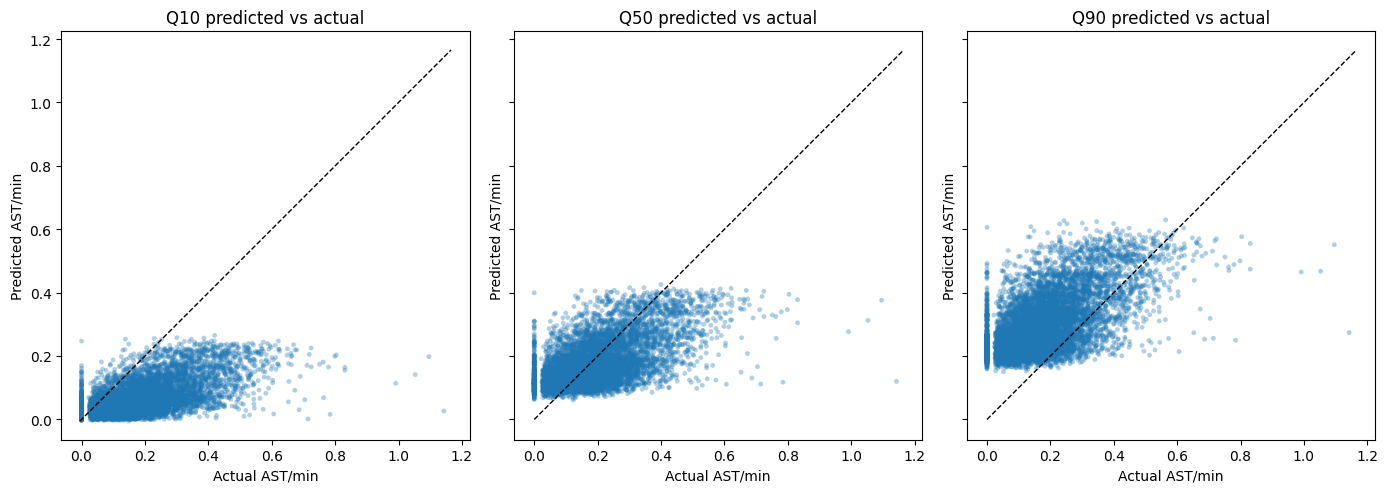

Q10 P(y ≤ pred): 0.10463787982636509
Q50 P(y ≤ pred): 0.5051405071967101
Q90 P(y ≤ pred): 0.8921635823623486
Coverage (10–90 interval): 78.75%


In [7]:
import matplotlib.pyplot as plt

y_true = y_val_f
preds = {
    "Q10": quantile_preds["q_0.10"],
    "Q50": quantile_preds["q_0.50"],
    "Q90": quantile_preds["q_0.90"],
}

fig, axes = plt.subplots(1, 3, figsize=(14, 6), sharex=True, sharey=True)
for ax, (name, y_pred) in zip(axes, preds.items()):
    ax.scatter(y_true, y_pred, s=12, edgecolors="none", alpha=0.35)
    lo = min(y_true.min(), y_pred.min())
    hi = max(y_true.max(), y_pred.max())
    lims = [lo, hi * 1.02 if hi > 0 else hi + 0.01]
    ax.plot(lims, lims, "k--", lw=1)
    ax.set_title(f"{name} predicted vs actual")
    ax.set_xlabel("Actual AST/min")
    ax.set_ylabel("Predicted AST/min")
    ax.set_aspect("equal", adjustable="box")
plt.tight_layout()
plt.show()

for name, y_pred in preds.items():
    print(name, "P(y ≤ pred):", (y_true <= y_pred).mean())

pred_low = quantile_preds["q_0.10"]
pred_mid = quantile_preds["q_0.50"]
pred_high = quantile_preds["q_0.90"]

coverage = ((y_true >= pred_low) & (y_true <= pred_high)).mean()
print(f"Coverage (10–90 interval): {coverage:.2%}")  # target ~80%

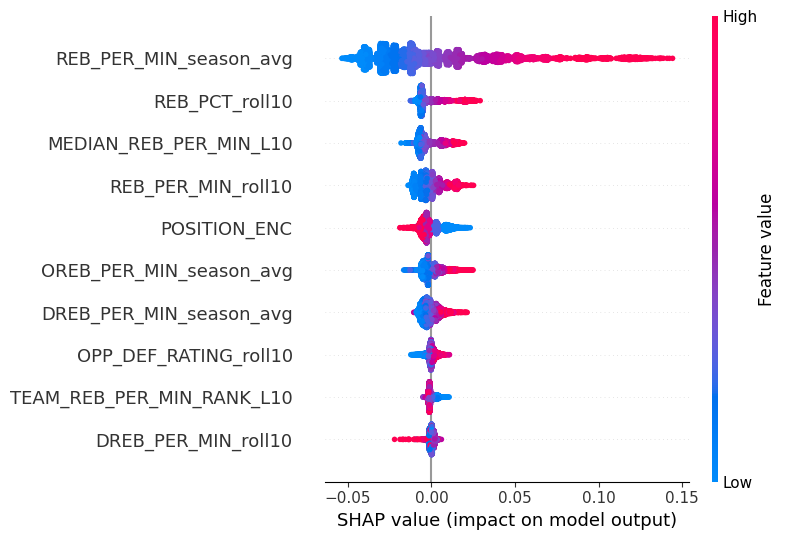

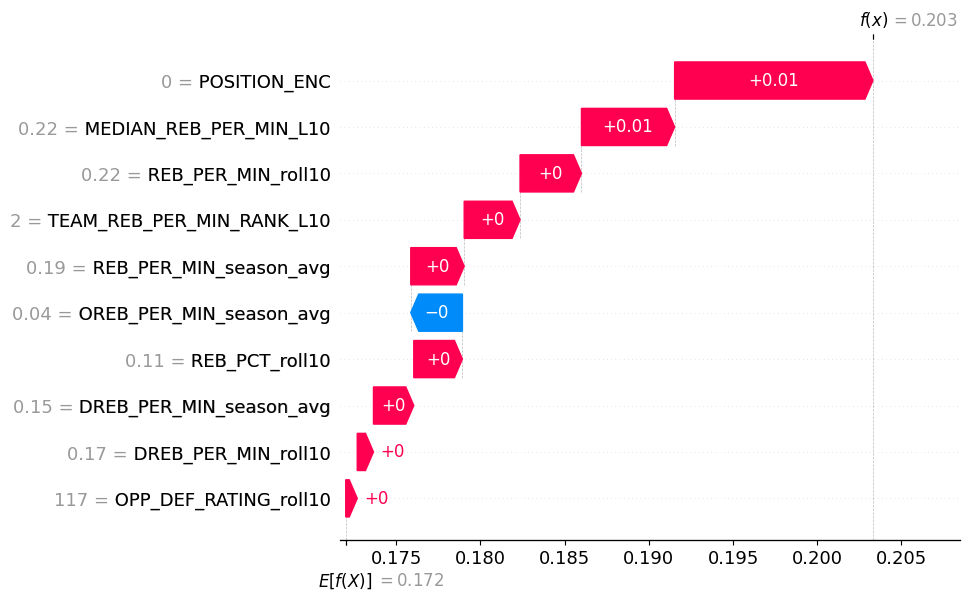

In [8]:
import shap

model = quantile_models["q_0.50"]   
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_val_f)
shap.summary_plot(shap_values, X_val_f, feature_names=RPM_FEATURES)
shap.plots.waterfall(shap_values[1154])

In [9]:
import joblib
from pathlib import Path

bundle = {
    "quantile_models": quantile_models,
    "feature_names": RPM_FEATURES,  # or list(X_train_min.columns)
}
joblib.dump(bundle, "src/models/saved_models/rpm_quantile_xgb.joblib")

['src/models/saved_models/rpm_quantile_xgb.joblib']

In [5]:
date = pd.Timestamp.now().normalize()  # midnight today, local tz
current_date = date.strftime("%Y-%m-%d")

# target_date = pd.Timestamp("2026-03-26")
# hist = df[df["GAME_DATE"] < target_date].copy()

lines_dfs = pd.read_csv('data/raw/player_lines/NBA_DFS_20260403_163051.csv')
lines_us = pd.read_csv('data/raw/player_lines/NBA_US_20260403_163203.csv')
lines_dfs = lines_dfs[(lines_dfs['BOOKMAKER'] == 'Underdog') & (lines_dfs['CATEGORY'] == 'player_rebounds')]
names = lines_dfs['NAME'].unique()
names

array(['Onyeka Okongwu', 'Mouhamed Gueye', 'Drake Powell', 'Noah Clowney',
       'Jalen Brunson', 'Josh Giddey', 'Isaac Okoro', 'Jayson Tatum',
       'Payton Pritchard', 'Neemias Queta', 'Jericho Sims', 'A.J. Green',
       'Alperen Sengun', 'Jabari Smith Jr', 'Amen Thompson',
       'Brice Sensabaugh', 'Collin Murray-Boyles', 'Javon Small',
       'Wendell Carter Jr', 'Zion Williamson', 'Saddiq Bey',
       'Derik Queen', 'Jeremiah Fears', 'Nique Clifford', 'Nikola Jokic',
       'Devin Vassell', 'Aaron Gordon', 'Cameron Johnson',
       'Julian Champagnie'], dtype=object)

In [6]:
import joblib

min_bundle = joblib.load("src/models/saved_models/min_quantile_xgb.joblib")
min_quantile_models = min_bundle["quantile_models"]
min_feature_names = min_bundle["feature_names"]

rpm_bundle = joblib.load("src/models/saved_models/rpm_quantile_xgb.joblib")
rpm_quantile_models = rpm_bundle["quantile_models"]
rpm_feature_names = rpm_bundle["feature_names"]

## MIN + RPM (ANALYSIS)

In [7]:
records = []

for name in names:
    try:
        if name in nameDict:
            name = nameDict[name]

        min_feats = min_pipeline(df, name)
        if min_feats is None:
            raise ValueError("min_pipeline returned None (need >= 10 games)")

        rpm_feats = rpm_pipeline(df, name, current_date)
        # ppm_pipeline returns a list aligned with PPM_FEATURES / training columns

        min_arr = np.asarray(min_feats, dtype=float).reshape(1, -1)
        rpm_arr = np.asarray(rpm_feats, dtype=float).reshape(1, -1)

        m10 = float(min_quantile_models["q_0.10"].predict(min_arr)[0])
        m50 = float(min_quantile_models["q_0.50"].predict(min_arr)[0])
        m90 = float(min_quantile_models["q_0.90"].predict(min_arr)[0])

        p10 = float(rpm_quantile_models["q_0.10"].predict(rpm_arr)[0])
        p50 = float(rpm_quantile_models["q_0.50"].predict(rpm_arr)[0])
        p90 = float(rpm_quantile_models["q_0.90"].predict(rpm_arr)[0])

        # implied PTS = minutes × PTS per minute (same quantile index on both sides)
        pts10 = m10 * p10
        pts50 = m50 * p50
        pts90 = m90 * p90

        records.append({
            "PLAYER_NAME": name,
            "PRED_MIN_Q10": m10,
            "PRED_MIN_Q50": m50,
            "PRED_MIN_Q90": m90,
            "PRED_RPM_Q10": p10,
            "PRED_RPM_Q50": p50,
            "PRED_RPM_Q90": p90,
            "PRED_REB_Q10": round(pts10, 2),
            "PRED_REB_Q50": round(pts50, 2),
            "PRED_REB_Q90": round(pts90, 2),
            "PRED_REB_RANGE_10_90": round(pts90 - pts10, 2),
        })

    except Exception as e:
        records.append({
            "PLAYER_NAME": name,
            "PRED_MIN_Q10": np.nan,
            "PRED_MIN_Q50": np.nan,
            "PRED_MIN_Q90": np.nan,
            "PRED_RPM_Q10": np.nan,
            "PRED_RPM_Q50": np.nan,
            "PRED_RPM_Q90": np.nan,
            "PRED_REB_Q10": np.nan,
            "PRED_REB_Q50": np.nan,
            "PRED_REB_Q90": np.nan,
            "PRED_REB_RANGE_10_90": np.nan,
        })
        print(f"[SKIP] {name}: {e}")

preds_df = pd.DataFrame(records)
preds_df.head()

[SKIP] A.J. Green: min_pipeline returned None (need >= 10 games)
[SKIP] Wendell Carter Jr: min_pipeline returned None (need >= 10 games)


,PLAYER_NAME,PRED_MIN_Q10,PRED_MIN_Q50,PRED_MIN_Q90,PRED_RPM_Q10,PRED_RPM_Q50,PRED_RPM_Q90,PRED_REB_Q10,PRED_REB_Q50,PRED_REB_Q90,PRED_REB_RANGE_10_90
0,Onyeka Okongwu,21.597481,29.285728,35.174381,0.142056,0.277640,0.429435,3.07,8.13,15.11,12.04
1,Mouhamed Gueye,10.524119,20.516014,28.790682,0.174265,0.238183,0.449811,1.83,4.89,12.95,11.12
2,Drake Powell,18.227821,27.317287,33.370060,0.020171,0.073065,0.151459,0.37,2.00,5.05,4.69
3,Noah Clowney,13.896731,20.445385,25.471516,0.056366,0.148634,0.319443,0.78,3.04,8.14,7.35
4,Jalen Brunson,30.662828,36.435535,39.150387,0.020125,0.097028,0.184808,0.62,3.54,7.24,6.62


In [8]:
import numpy as np
import pandas as pd

# ---------------------------------------------------------
# 1. THE CORE SIMULATION ENGINE (POISSON-BASED)
# ---------------------------------------------------------

def triangular_clip(row, q10, q50, q90, lo_scale=0.70, hi_scale=1.30, low=0.0, high=np.inf, n_sims=10_000):
    """
    Generates a triangular distribution based on XGBoost quantiles.
    Widening the scales (lo_scale, hi_scale) introduces 'NBA Chaos' (fouls, blowouts).
    """
    mode = float(row[q50])
    # Ensure left < mode < right
    left = min(float(row[q10]) * lo_scale, mode - 0.001)
    right = max(float(row[q90]) * hi_scale, mode + 0.001)
    
    if not (np.isfinite(left) and np.isfinite(mode) and np.isfinite(right)):
        return np.full(n_sims, mode if np.isfinite(mode) else 0.0)
    
    # Generate continuous samples
    samples = np.random.triangular(left, mode, right, size=n_sims)
    return np.clip(samples, low, high)

def run_stat_simulation(row, stat_prefix="RPM", n_sims=10_000):
    """
    Paired simulation: Minutes * Rate.
    Converts expected continuous value into discrete integers using Poisson.
    """
    # Simulate Minutes
    sim_min = triangular_clip(
        row,
        "PRED_MIN_Q10", "PRED_MIN_Q50", "PRED_MIN_Q90",
        lo_scale=0.75, hi_scale=1.25, low=0, high=48, n_sims=n_sims,
    )
    
    # Simulate Rate (APM or RPM)
    sim_rate = triangular_clip(
        row,
        f"PRED_{stat_prefix}_Q10", f"PRED_{stat_prefix}_Q50", f"PRED_{stat_prefix}_Q90",
        lo_scale=0.70, hi_scale=1.30, low=0, high=np.inf, n_sims=n_sims,
    )
    
    # Calculate Lambda (Expected value for each sim)
    expected_val = sim_min * sim_rate
    
    # Poisson Sampling: The 'Counting' Step
    # This turns 7.4 expected rebounds into a distribution of 6, 7, 8, 9...
    sim_counts = np.random.poisson(lam=expected_val)
    
    return sim_counts

# ---------------------------------------------------------
# 2. LINE LOOKUP & MAPPING
# ---------------------------------------------------------

def _line_lookup_from_lines_df(ldf: pd.DataFrame, name_dict: dict) -> dict:
    """
    Maps sportsbook names to canonical dataset names.
    Handles 'Jokic' vs 'Jokić' logic.
    """
    d = {}
    for _, r in ldf.iterrows():
        book_name = str(r["NAME"]).strip()
        line = r["LINE"]
        d[book_name] = line
        
        # Add the canonical version if it exists in your nameDict
        canon = name_dict.get(book_name)
        if canon:
            d[canon] = line
            
    # Reverse check: ensure variants point to the line if canon was found
    for variant, canon in name_dict.items():
        if canon in d and variant not in d:
            d[variant] = d[canon]
    return d

# ---------------------------------------------------------
# 3. EXECUTION LOOP
# ---------------------------------------------------------

# Build the lookup
line_by_name = _line_lookup_from_lines_df(lines_dfs, nameDict)

results = []
for _, row in preds_df.iterrows():
    name = row["PLAYER_NAME"]
    line = line_by_name.get(name)
    
    # Validation
    if line is None or np.isnan(row.get("PRED_MIN_Q50", np.nan)):
        results.append({
            "PLAYER_NAME": name, "LINE": np.nan, 
            "P_OVER": np.nan, "P_UNDER": np.nan, "P_PUSH": np.nan
        })
        continue

    # Run the Poisson Simulation (Change prefix to 'APM' for Assists)
    stat_sims = run_stat_simulation(row, stat_prefix="RPM", n_sims=10_000)
    line = float(line)
    
    # Calculate Integer-Aware Probabilities
    p_over = float(np.mean(stat_sims > line))
    p_under = float(np.mean(stat_sims < line))
    p_push = float(np.mean(stat_sims == line))

    # Calculate Edge and EV
    # Assuming -119 odds (~1.84x payout) for Underdog standard
    # EV = (P_win * Profit) - (P_loss * Stake)
    # Simplified here for relative ranking:
    edge = row["PRED_REB_Q50"] - line 
    
    results.append({
        "PLAYER_NAME": name,
        "LINE": line,
        "PRED_MIN_Q50": round(row["PRED_MIN_Q50"], 2), 
        "PRED_STAT_Q50": round(row["PRED_REB_Q50"], 2),
        "P_OVER": round(p_over, 3), 
        "P_UNDER": round(p_under, 3),
        "P_PUSH": round(p_push, 3),
        "EDGE": round(edge, 2),
        "EV": round((p_over * 10) - (p_under * 10), 2) # Weighted directional EV
    })

# Create final DataFrame
line_probs_df = pd.DataFrame(results)

# Sort by absolute edge to find the biggest discrepancies
line_probs_df['ABS_EDGE'] = line_probs_df['EDGE'].abs()
line_probs_df = line_probs_df.sort_values(by="ABS_EDGE", ascending=False)

# Display top plays
print(line_probs_df[['PLAYER_NAME', 'LINE', 'PRED_STAT_Q50', 'P_OVER', 'P_UNDER', 'P_PUSH', 'EDGE']].head(15))

         PLAYER_NAME  LINE  PRED_STAT_Q50  P_OVER  P_UNDER  P_PUSH  EDGE
10      Jericho Sims   7.5           5.24   0.329    0.671     0.0 -2.26
12    Alperen Sengun   8.5          10.05   0.660    0.340     0.0  1.55
1     Mouhamed Gueye   3.5           4.89   0.799    0.201     0.0  1.39
26      Aaron Gordon   4.5           5.73   0.717    0.283     0.0  1.23
5        Josh Giddey   7.5           8.61   0.633    0.367     0.0  1.11
21       Derik Queen   6.5           7.53   0.680    0.320     0.0  1.03
14     Amen Thompson   7.5           8.46   0.619    0.381     0.0  0.96
25     Devin Vassell   3.5           4.31   0.689    0.311     0.0  0.81
7       Jayson Tatum   8.5           9.25   0.673    0.327     0.0  0.75
6        Isaac Okoro   2.5           3.18   0.695    0.305     0.0  0.68
0     Onyeka Okongwu   7.5           8.13   0.613    0.387     0.0  0.63
24      Nikola Jokić  13.5          14.02   0.551    0.449     0.0  0.52
2       Drake Powell   2.5           2.00   0.447  